In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.layers import Conv2D, Dense, MaxPool2D,Flatten,GlobalAveragePooling2D,BatchNormalization,Dropout,Activation
from keras.models import Model
import numpy as np
from matplotlib import pyplot as plt
print("GPUs:", tf.config.list_physical_devices('GPU'))

2026-02-15 16:35:16.694063: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-15 16:35:16.733995: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-15 16:35:17.904218: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


loading the data


In [3]:
train_ds=keras.utils.image_dataset_from_directory("tiny-imagenet/train", labels="inferred",label_mode="int",batch_size=32, image_size=(128,128))
val_ds=keras.utils.image_dataset_from_directory("tiny-imagenet/val", labels="inferred",label_mode="int",batch_size=32, image_size=(128,128))
test_ds=keras.utils.image_dataset_from_directory("tiny-imagenet/test", labels="inferred",label_mode="int",batch_size=32, image_size=(128,128))


Found 3500 files belonging to 10 classes.
Found 500 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.


In [4]:
def process(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label
train_ds = train_ds.map(process)
val_ds = val_ds.map(process)
test_ds = test_ds.map(process)

#creating model without batch normalization

In [ ]:
inputs=layers.Input(shape=(128,128,3))
x=Conv2D(12,kernel_size=(3,3),padding="same",activation="relu",input_shape=(128,128,3))(inputs)
x=Conv2D(12,kernel_size=(3,3),padding="same",activation="relu")(x)
x=MaxPool2D(pool_size=(2,2),strides=2,padding="same")(x)

x=Conv2D(24,kernel_size=(3,3),padding="same",activation="relu")(x)
x=Conv2D(24,kernel_size=(3,3),padding="same",activation="relu")(x)
x=MaxPool2D(pool_size=(2,2),strides=2,padding="same")(x)

x=Conv2D(48,kernel_size=(3,3),padding="same",activation="relu",name="layer5")(x)
x=Conv2D(48,kernel_size=(3,3),padding="same",activation="relu")(x)
x=GlobalAveragePooling2D()(x)

x=Dense(32,activation="relu")(x)
outputs=Dense(10,activation="softmax")(x)
model=Model(inputs=inputs,outputs=outputs)
model.summary()

/home/akshat/anaconda3/envs/dl/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 12)   │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 12)   │         1,308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 24)     │         2,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer5 (Conv2D)                 │ (None, 32, 32, 48)     │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 48)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,566 (166.27 KB)

 Trainable params: 42,566 (166.27 KB)

 Non-trainable params: 0 (0.00 B)

Training the model without Batch Normalization

In [7]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0006),loss=keras.losses.SparseCategoricalCrossentropy(),metrics=["accuracy"])
model.fit(train_ds,validation_data=val_ds,epochs=50,callbacks=[keras.callbacks.EarlyStopping(patience=10)])

Epoch 1/50


2026-02-15 15:16:26.677695: I external/local_xla/xla/service/service.cc:163] XLA service 0x7b9da400d430 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-15 15:16:26.677743: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6
2026-02-15 15:16:26.759891: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-15 15:16:26.960512: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


  9/110 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0760 - loss: 2.3025

I0000 00:00:1771148791.151136    4601 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - accuracy: 0.1900 - loss: 2.0898 - val_accuracy: 0.2320 - val_loss: 1.8886
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2600 - loss: 1.8523 - val_accuracy: 0.3140 - val_loss: 1.7308
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2994 - loss: 1.7180 - val_accuracy: 0.3300 - val_loss: 1.6498
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3386 - loss: 1.6644 - val_accuracy: 0.3720 - val_loss: 1.6217
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3440 - loss: 1.6633 - val_accuracy: 0.3600 - val_loss: 1.6228
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3669 - loss: 1.6313 - val_accuracy: 0.3820 - val_loss: 1.6858
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3834 - loss: 1.5929 - val_accuracy: 0.3760 - val_loss: 1.5730
Epoch 8/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3957 - loss: 1.5740 - val_accuracy: 0.37

Testing the model without Batch Normalization

In [8]:
test_loss,test_acc=model.evaluate(test_ds)
print("Test Loss: ",test_loss)
print("Test Accuracy: ",test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6010 - loss: 1.1521
Test Loss:  1.1520769596099854
Test Accuracy:  0.6010000109672546


Creating Model with Batch Normalization

In [12]:

inputs2=layers.Input(shape=(128,128,3))
x=Conv2D(12,kernel_size=(3,3),padding="same",input_shape=(128,128,3))(inputs2)
x=BatchNormalization()(x)
x=Activation("relu")(x)
x=Conv2D(12,kernel_size=(3,3),padding="same")(x)
x=BatchNormalization()(x)
x=Activation("relu")(x)
x=MaxPool2D(pool_size=(2,2),strides=2,padding="same")(x)
x=Dropout(0.1)(x)

x=Conv2D(24,kernel_size=(3,3),padding="same")(x)
x=BatchNormalization()(x)
x=Activation("relu")(x)
x=Conv2D(24,kernel_size=(3,3),padding="same")(x)
x=BatchNormalization()(x)
x=Activation("relu")(x)
x=MaxPool2D(pool_size=(2,2),strides=2,padding="same")(x)
x=Dropout(0.25)(x)

x=Conv2D(48,kernel_size=(3,3),padding="same")(x)
x=BatchNormalization(name="layer5")(x)
x=Activation("relu")(x)
x=Conv2D(48,kernel_size=(3,3),padding="same")(x)
x=BatchNormalization()(x)
x=Activation("relu")(x)
x=MaxPool2D(pool_size=(2,2),strides=2,padding="same")(x)
x=Dropout(0.25)(x)
x=GlobalAveragePooling2D()(x)
x=Dense(32,activation="relu")(x)
x=BatchNormalization()(x)
x=Dropout(0.25)(x)
# x=Dense(32,activation="relu")(x)
# x=Dropout(0.4)(x)
outputs2=Dense(10,activation="softmax")(x)
model2=Model(inputs=inputs2,outputs=outputs2)
model2.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 128, 128, 12)   │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 128, 12)   │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 128, 128, 12)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 128, 128, 12)   │         1,308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128, 128, 12)   │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 128, 128, 12)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64, 64, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 24)     │         2,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64, 64, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 64, 64, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 64, 64, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64, 64, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 64, 64, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 48)     │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer5 (BatchNormalization)     │ (None, 32, 32, 48)     │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 32, 32, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 43,366 (169.40 KB)

 Trainable params: 42,966 (167.84 KB)

 Non-trainable params: 400 (1.56 KB)

Training the Model with Batch Normalization

In [13]:
model2.compile(optimizer="adam",loss=keras.losses.SparseCategoricalCrossentropy(),metrics=["accuracy"])
model2.fit(train_ds,validation_data=val_ds,epochs=55,callbacks=[keras.callbacks.EarlyStopping(patience=12,restore_best_weights=True)])

Epoch 1/55
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.3214 - loss: 1.8823 - val_accuracy: 0.1000 - val_loss: 2.4213
Epoch 2/55
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4046 - loss: 1.6355 - val_accuracy: 0.1120 - val_loss: 2.6265
Epoch 3/55
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4351 - loss: 1.5411 - val_accuracy: 0.1900 - val_loss: 2.5619
Epoch 4/55
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4437 - loss: 1.4861 - val_accuracy: 0.2640 - val_loss: 1.9582
Epoch 5/55
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4677 - loss: 1.4318 - val_accuracy: 0.4000 - val_loss: 1.5895
Epoch 6/55
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4877 - loss: 1.3598 - val_accuracy: 0.4600 - val_loss: 1.3818
Epoch 7/55
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5174 - loss: 1.3054 - val_accuracy: 0.4640 - val_loss: 1.5136
Epoch 8/55
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5246 - loss: 1.2867 - val_acc

Testing the Model with Batch Normalization

In [14]:
test_loss,test_acc=model2.evaluate(test_ds)
print("Test Loss: ",test_loss)
print("Test Accuracy: ",test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6690 - loss: 0.9632
Test Loss:  0.9632336497306824
Test Accuracy:  0.6690000295639038


Plotting the mean and variance for Internal Covariate Shift

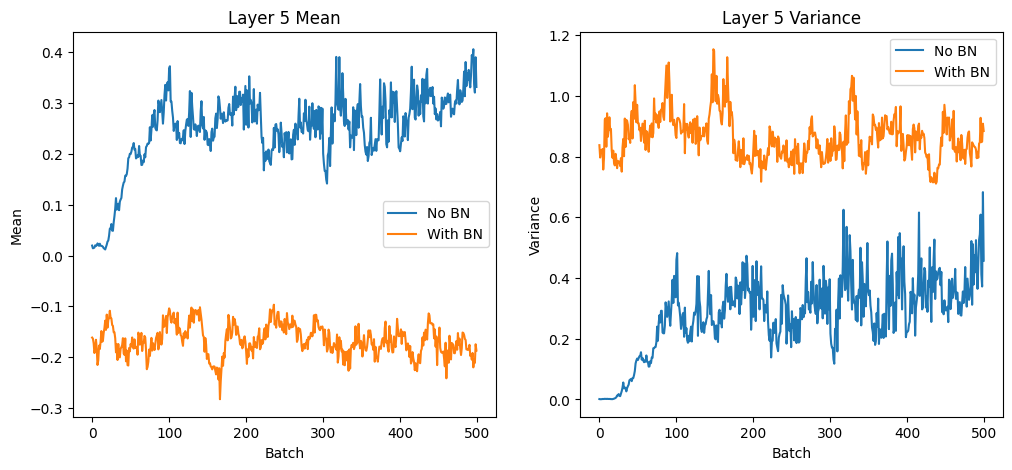

In [15]:
train_ds = train_ds.shuffle(1000).repeat()
dataset_iter = iter(train_ds)

num_batches = 500
model3=Model(inputs=inputs,outputs=outputs)
model4=Model(inputs=inputs2,outputs=outputs2)
model3.compile(optimizer="adam",loss=keras.losses.SparseCategoricalCrossentropy(),metrics=["accuracy"])
model4.compile(optimizer="adam",loss=keras.losses.SparseCategoricalCrossentropy(),metrics=["accuracy"])
activ_nobatch=Model(model3.input,model3.get_layer("layer5").output)
activ_batch=Model(model4.input,model4.get_layer("layer5").output)
mean_nobatch,var_nobatch=[],[]
mean_batch,var_batch=[],[]
for i in range(num_batches):
    x,y=next(dataset_iter)
    model3.train_on_batch(x,y)
    model4.train_on_batch(x,y)
    act3=activ_nobatch(x,training=False).numpy()
    act4=activ_batch(x,training=False).numpy()
    mean_nobatch.append(np.mean(act3))
    var_nobatch.append(np.var(act3))
    mean_batch.append(np.mean(act4))
    var_batch.append(np.var(act4))
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(mean_nobatch, label="No BN")
plt.plot(mean_batch, label="With BN")
plt.title("Layer 5 Mean")
plt.xlabel("Batch")
plt.ylabel("Mean")
plt.legend()

plt.subplot(1,2,2)
plt.plot(var_nobatch, label="No BN")
plt.plot(var_batch, label="With BN")
plt.title("Layer 5 Variance")
plt.xlabel("Batch")
plt.ylabel("Variance")
plt.legend()

plt.show()